# Quality (KS4)

author: steeve.laquitaine@epfl.ch  
last modified: 13-02-2024

**author**: laquitainesteeve@gmail.com

**purpose**: Plot sorting quality (spike assigment biases) of single-units by experiment for KS4.

**tested on**:

* Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz) with RTX 5090 GPU with 40GB VRAM (GPU not needed)

### Setup

1. Create or activate env `spikeinterf...`
2. Compute dataset: `sbatch cluster/analysis/sorting_quality.sh`

In [9]:
%load_ext autoreload
%autoreload 2

# import built-in packages
import os 
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# set project path
proj_path = "/home/steeve/steeve/epfl/code/spikebias"
os.chdir(proj_path)

# import custom packages
from src.nodes import utils
from src.nodes.metrics import quality

# pre-computed intermediate dataset
quality_path = "dataset/01_intermediate/quality/sorting_quality.csv"

# figure ticks parameterss
N_MJ_TCKS = 5
N_MN_TCKS = 11

# cell type color legend
colors = {"mixed: overmerger + oversplitter": [1,1,1],
          "mixed: good + overmerger + oversplitter": [0.8784, 0.4784, 0.5451]
          }

# axes
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6  # 5-7 with Nature neuroscience as reference
plt.rcParams["lines.linewidth"] = 0.5 # typically between 0.5 and 1
plt.rcParams["axes.linewidth"] = 0.5 #1
plt.rcParams["axes.spines.top"] = False
plt.rcParams["xtick.major.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["xtick.minor.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["ytick.major.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["ytick.minor.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["xtick.major.size"] = 3.5 * 1.1
plt.rcParams["xtick.minor.size"] = 2 * 1.1
plt.rcParams["ytick.major.size"] = 3.5 * 1.1
plt.rcParams["ytick.minor.size"] = 2 * 1.1

# saving parameters
savefig_cfg = {"transparent":True, "dpi": 300}

# legend
legend_cfg = {"frameon": False, "handletextpad": 0.5}
tight_layout_cfg = {"pad": 0.001}
LG_FRAMEON = False              # no legend frame

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Custom functions

In [10]:
def plot_source_data(df, colors):

    # spike sorters
    sorter = ["KS4"]

    # plot
    fig = plt.figure(figsize=(1.5, 2), layout="constrained")
    spec = fig.add_gridspec(ncols=len(sorter), nrows=4)

    # loop over sorter (grid columns)
    for s_ix, sorter_i in enumerate(sorter):

        # S
        ax = fig.add_subplot(spec[0, s_ix])

        # plot
        ax = quality._plot_ratio_by_layer(
            ax,
            df[(df["sorter"] == sorter_i) & (df["experiment"] == "S")],
            colors,
            legend_cfg,
            False,
            False,
        )
        ax.set_xlim([-4, 2])
        if s_ix == 0:
            ax.spines["left"].set_visible(True)
            ax.set_yticks([0, 50, 100], [0, 0.5, 1])
        else:
            ax.set_yticks([])
        ax.set_xticks([])

        # NS
        ax = fig.add_subplot(spec[1, s_ix])

        # plot
        ax = quality._plot_ratio_by_layer(
            ax,
            df[(df["sorter"] == sorter_i) & (df["experiment"] == "NS")],
            colors,
            legend_cfg,
            False,
            False,
        )
        if s_ix == 0:
            ax.spines["left"].set_visible(True)
            ax.set_yticks([0, 50, 100], [0, 0.5, 1])
        else:
            ax.set_yticks([])
        ax.set_xticks([])

        # DS
        ax = fig.add_subplot(spec[2, s_ix])

        # plot
        ax = quality._plot_ratio_by_layer(
            ax,
            df[(df["sorter"] == sorter_i) & (df["experiment"] == "DS")],
            colors,
            legend_cfg,
            False,
            False,
        )
        if s_ix == 0:
            ax.spines["left"].set_visible(True)
            ax.set_yticks([0, 50, 100], [0, 0.5, 1])
        else:
            ax.set_yticks([])
        ax.set_xticks([])

        # E
        ax = fig.add_subplot(spec[3, s_ix])

        # plot
        ax = quality._plot_ratio_by_layer(
            ax,
            df[(df["sorter"] == sorter_i) & (df["experiment"] == "E")],
            colors,
            legend_cfg,
            False,
            False,
        )
        if s_ix == 0:
            ax.spines["left"].set_visible(True)
            ax.set_yticks([0, 50, 100], [0, 0.5, 1])
        else:
            ax.set_yticks([])

    # build the two legend swatches by hand (they don't correspond to real bars)
    handles = [
        Patch(facecolor="white", edgecolor="black", label="merged + partial (degraded)", linewidth=0.5),
        Patch(facecolor=(0.8784, 0.4784, 0.5451), edgecolor="white", label="good + merged + partial"),
    ]

    # place legend in its own area to the right of the plot, with a bold title
    leg = ax.legend(
        handles=handles,
        title="Unit quality",
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),  # push legend outside the axes, to the right
        frameon=False,               # no box around the whole legend
        handlelength=1.5,
        handleheight=1.5,
    )
    leg.get_title().set_fontweight("bold")


    # format
    plt.subplots_adjust(wspace=0, hspace=1)
    return fig, ax

### Load dataset


In [11]:
%%time 

# read pre-computed data
df = pd.read_csv(quality_path)

# rename "outside" layer for plot
df[df["layer"] == "Outside"] = "Out"

# report
df

CPU times: user 5.96 ms, sys: 999 µs, total: 6.96 ms
Wall time: 6.77 ms


,sorted,quality,layer,sorter,experiment,Depth
0,239,false positive,L6,KS2.5,DS,3.0
1,739,false positive,L2/3,KS,DS,1.0
2,854,false positive,L5,KS2,E,NaN
3,724,false positive,L2/3,KS,DS,1.0
4,569,false positive,L6,KS,DS,3.0
...,...,...,...,...,...,...
16480,400,oversplitter,L2/3,KS,DS,1.0
16481,979,oversplitter,L6,KS,DS,3.0
16482,137,oversplitter,L5,KS2,DS,2.0
16483,1774,oversplitter,L5,KS,E,NaN


### Plot

CPU times: user 160 ms, sys: 1.01 ms, total: 161 ms
Wall time: 161 ms


/tmp/ipykernel_1203481/2285259499.py:109: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0, hspace=1)
<timed exec>:5: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
/home/steeve/steeve/epfl/code/spikebias/envs/spikebias/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


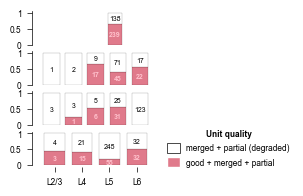

In [12]:
%%time 

# plot
fig, ax = plot_source_data(df, colors)

# save figures
plt.savefig("figures/8_source_data/fig5d/fig5d.svg", bbox_inches="tight", **savefig_cfg)

In [13]:
%%time 

# report sorted types 
print("NS:\n", df[(df["sorter"] == "KS4") & (df["experiment"] == "NS")]["quality"].unique())
print("E:\n", df[(df["sorter"] == "KS4") & (df["experiment"] == "E")]["quality"].unique())
print("DS:\n", df[(df["sorter"] == "KS4") & (df["experiment"] == "DS")]["quality"].unique())
print("S:\n", df[(df["sorter"] == "KS4") & (df["experiment"] == "S")]["quality"].unique())

NS:
 ['mixed: good + overmerger + oversplitter'
 'mixed: overmerger + oversplitter']
E:
 ['mixed: good + overmerger + oversplitter'
 'mixed: overmerger + oversplitter']
DS:
 ['mixed: good + overmerger + oversplitter'
 'mixed: overmerger + oversplitter']
S:
 ['mixed: good + overmerger + oversplitter'
 'mixed: overmerger + oversplitter']
CPU times: user 4.41 ms, sys: 23 µs, total: 4.43 ms
Wall time: 4.23 ms


### Create source data 

In [14]:
%%time 

df.to_excel("figures/8_source_data/fig5d/fig5d.xlsx", index=False)

CPU times: user 896 ms, sys: 13.9 ms, total: 910 ms
Wall time: 911 ms


### Load

In [15]:
%%time 

df = pd.read_excel("figures/8_source_data/fig5d/fig5d.xlsx")

CPU times: user 660 ms, sys: 3.96 ms, total: 664 ms
Wall time: 664 ms


### Re-plot

CPU times: user 66.9 ms, sys: 0 ns, total: 66.9 ms
Wall time: 66.3 ms


/tmp/ipykernel_1203481/2285259499.py:109: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0, hspace=1)
/home/steeve/steeve/epfl/code/spikebias/envs/spikebias/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  func(*args, **kwargs)
/home/steeve/steeve/epfl/code/spikebias/envs/spikebias/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


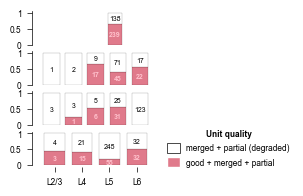

In [16]:
%%time 

# plot
fig, ax = plot_source_data(df, colors)